# XOR

devices: [CudaDevice(id=0)]
Cloning into 'Neuroevolution'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 133 (delta 68), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 76.94 KiB | 2.85 MiB/s, done.
Resolving deltas: 100% (68/68), done.


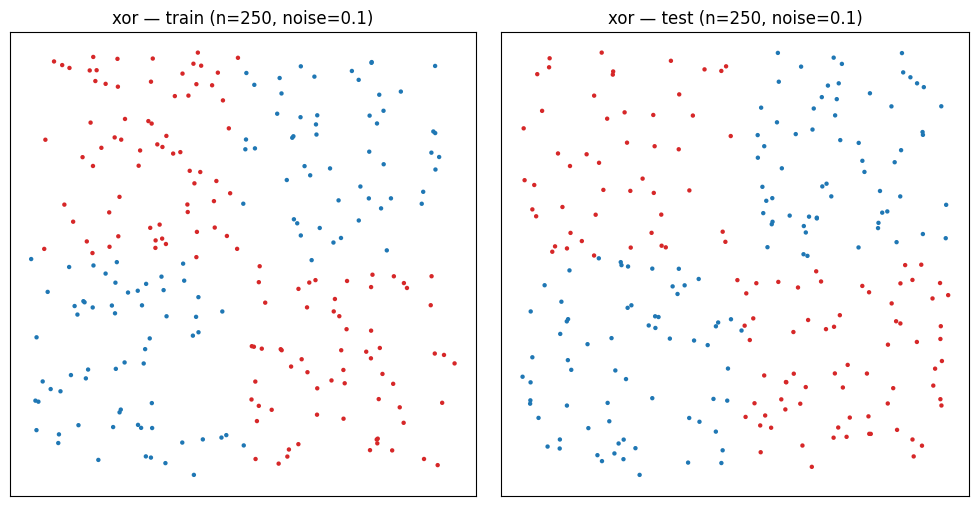

[xor]  gen |    fit max    mean |  acc best tr/te | mean te | species (new/ext,max) | best h/c/d | pop h/c | stag |  time
         0 |   -0.705  -0.722 |      0.69/0.60 |   0.56 |     1 (+1 -0, 120) |   0/  3/ 1 |  0.0/  3.0 |    0 |  11.9s
           sp   0: fit   -0.705 size 120 | h  0 c   3 d  1 | -
         1 |   -0.703  -0.705 |      0.56/0.47 |   0.59 |     1 (+0 -0, 120) |   1/  4/ 2 |  0.2/  3.2 |    0 |   7.9s
           sp   0: fit   -0.703 size 120 | h  1 c   4 d  2 | gauss:1
         2 |   -0.402  -0.697 |      0.83/0.78 |   0.57 |     5 (+4 -0, 69) |   1/  6/ 2 |  0.5/  3.6 |    0 |   8.8s
           sp   1: fit   -0.402 size  33 | h  1 c   6 d  2 | square:1
           sp   4: fit   -0.704 size   4 | h  1 c   4 d  2 | abs:1
           sp   0: fit   -0.705 size  69 | h  0 c   3 d  1 | -
         3 |   -0.354  -0.642 |      0.84/0.76 |   0.60 |     2 (+0 -3, 61) |   1/  5/ 2 |  1.0/  4.8 |    0 |   8.1s
           sp   1: fit   -0.354 size  61 | h  1 c   5 d  2 | square:1
  

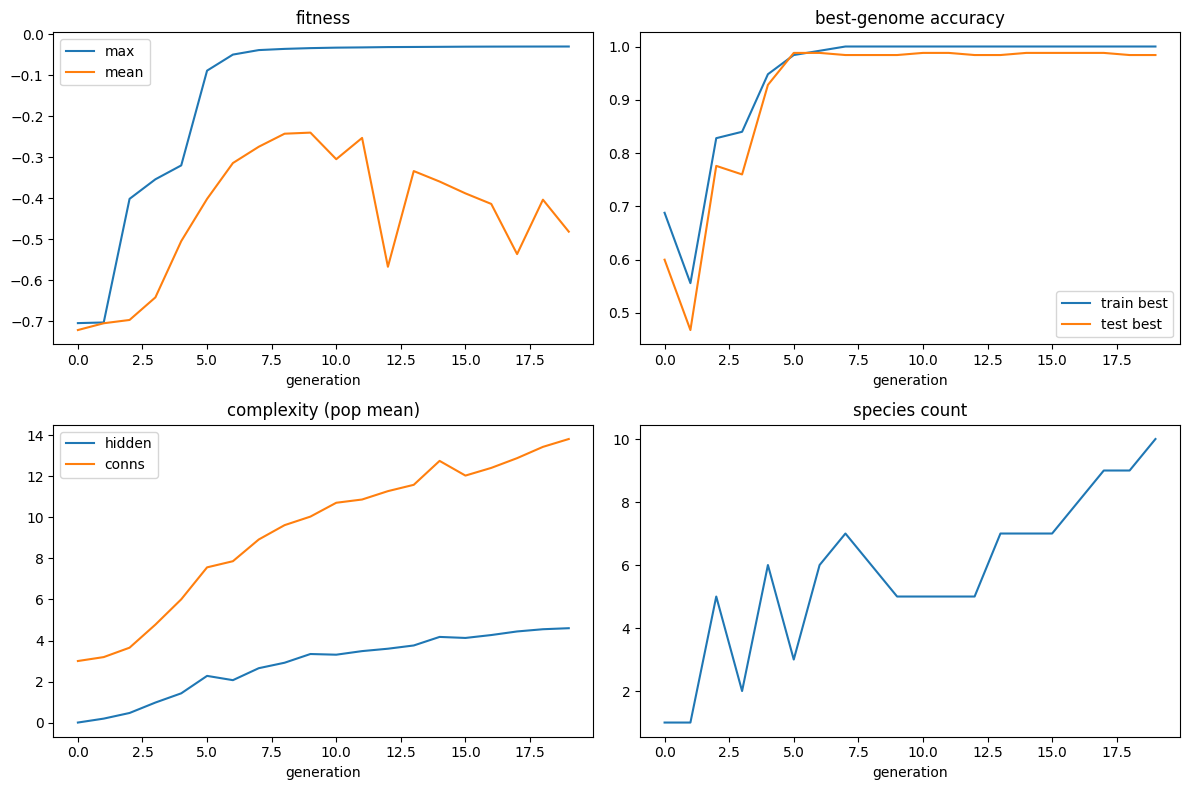

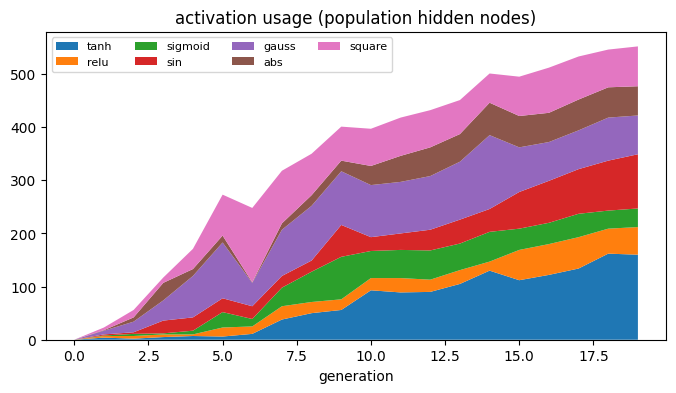

In [1]:
# %% [markdown]
# Backprop NEAT on 2D classification (circle / XOR / spiral) — Colab runner.
# NEAT evolves topology; backprop (Adam) fits the weights of each network.
# Runtime > Change runtime type > GPU is optional (small problems run on CPU too).

# %% Confirm JAX sees a device.
# Colab ships JAX preinstalled and version-matched on a FRESH runtime — do not
# reinstall/upgrade jax (that causes the PJRT "expected 48, got 40" mismatch).
# If you ever hit that error, just Runtime > Disconnect and delete runtime, then
# run from the top.
import jax
print("devices:", jax.devices())   # CudaDevice on GPU runtime, else CPU

# %% Clone the library (BackpropNEAT branch) and make it importable
!rm -rf Neuroevolution
!git clone -b BackpropNEAT https://github.com/yugoguy/Neuroevolution.git
import sys
sys.path.append("/content/Neuroevolution")

# %% Hyperparameters
#@markdown ### Task
dataset = "xor"        #@param ["circle", "xor", "spiral"]
n_train = 250             #@param {type:"integer"}
n_test = 250              #@param {type:"integer"}
noise = 0.1               #@param {type:"number"}

#@markdown ### Run
pop_size = 120            #@param {type:"integer"}
num_generations = 20      #@param {type:"integer"}
n_max = 32                #@param {type:"integer"}
seed = 0                  #@param {type:"integer"}

#@markdown ### Backprop inner loop
backprop_steps = 100      #@param {type:"integer"}
learning_rate = 0.01      #@param {type:"number"}
num_passes = 32           #@param {type:"integer"}

#@markdown ### Complexity penalty
penalty_conn = 0.01       #@param {type:"number"}
penalty_node = 0.0        #@param {type:"number"}

#@markdown ### Initialization
weight_init_std = 0.5     #@param {type:"number"}

#@markdown ### Mutation (structural ops are NEAT's; weight mutation only jitters the backprop warm-start)
p_weight = 0.2            #@param {type:"number"}
perturb_std = 0.1         #@param {type:"number"}
replace_prob = 0.05       #@param {type:"number"}
p_add_connection = 0.3    #@param {type:"number"}
p_add_node = 0.15         #@param {type:"number"}
p_activation = 0.1        #@param {type:"number"}
add_conn_max_tries = 20   #@param {type:"integer"}
new_node_activation = "random"  #@param ["random", "tanh", "relu", "sigmoid", "sin", "gauss", "abs", "square"]

#@markdown ### Crossover
reenable_prob = 0.25             #@param {type:"number"}
inherit_from_fitter_prob = 0.5   #@param {type:"number"}
interspecies_mating_prob = 0.001 #@param {type:"number"}

#@markdown ### Speciation
compat_threshold = 0.75    #@param {type:"number"}
c_unmatched = 1.0         #@param {type:"number"}
c_weight = 0.4            #@param {type:"number"}
normalize_threshold = 0  #@param {type:"integer"}
rep_selection = "random"  #@param ["random", "first"]

#@markdown ### Reproduction
survival_threshold = 0.3        #@param {type:"number"}
elitism_min_species_size = 5    #@param {type:"integer"}
mutate_only_prob = 0.25         #@param {type:"number"}
parent_selection = "uniform"    #@param ["uniform", "fitness_weighted"]
max_stagnation = 15             #@param {type:"integer"}
population_stall = 20           #@param {type:"integer"}

from config import Config
cfg = Config(
    dataset=dataset, n_train=n_train, n_test=n_test, noise=noise,
    pop_size=pop_size, num_generations=num_generations, n_max=n_max, seed=seed,
    backprop_steps=backprop_steps, learning_rate=learning_rate, num_passes=num_passes,
    penalty_conn=penalty_conn, penalty_node=penalty_node,
    weight_init_std=weight_init_std,
    p_weight=p_weight, perturb_std=perturb_std, replace_prob=replace_prob,
    p_add_connection=p_add_connection, p_add_node=p_add_node, p_activation=p_activation,
    add_conn_max_tries=add_conn_max_tries, new_node_activation=new_node_activation,
    reenable_prob=reenable_prob, inherit_from_fitter_prob=inherit_from_fitter_prob,
    interspecies_mating_prob=interspecies_mating_prob,
    compat_threshold=compat_threshold, c_unmatched=c_unmatched, c_weight=c_weight,
    normalize_threshold=normalize_threshold, rep_selection=rep_selection,
    survival_threshold=survival_threshold, elitism_min_species_size=elitism_min_species_size,
    mutate_only_prob=mutate_only_prob, parent_selection=parent_selection,
    max_stagnation=max_stagnation, population_stall=population_stall,
)

# %% Visualize the dataset first (same RNG sequence evolve uses, so this is the
# actual train/test split the networks are scored on)
import numpy as np
import matplotlib.pyplot as plt
from dataset import make_dataset
_drng = np.random.default_rng(cfg.seed + 1)
Xtr, ytr = make_dataset(cfg.dataset, cfg.n_train, _drng, cfg.noise)
Xte, yte = make_dataset(cfg.dataset, cfg.n_test, _drng, cfg.noise)
fig, axd = plt.subplots(1, 2, figsize=(10, 5))
for a, (X, y, name) in zip(axd, [(Xtr, ytr, "train"), (Xte, yte, "test")]):
    a.scatter(X[y == 0, 0], X[y == 0, 1], s=10, c="tab:red", edgecolors="none")
    a.scatter(X[y == 1, 0], X[y == 1, 1], s=10, c="tab:blue", edgecolors="none")
    a.set_title(f"{cfg.dataset} — {name} (n={len(y)}, noise={cfg.noise})")
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# %% Run evolution (first generation is slow due to JIT compilation)
from orchestrator import evolve
best, rec = evolve(cfg)
rec.dump_json("history.json")
print("best fitness:", rec.records[-1]["best"]["fitness"])
print("best test acc:", rec.records[-1].get("accuracy", {}).get("test_best"))

# %% Top-species report (reconstructed from the recorder, so it always prints
# regardless of what orchestrator version produced the run). For the requested
# generations it lists, per top species, the BEST genome's fitness, size,
# structure (hidden / connections / depth) and which activations it uses.
from collections import Counter
from recorder import load_genome
from graph_utils import max_depth

def species_report(gen, top_k=6):
    r = rec.records[gen]
    sfit = {int(s): v for s, v in r["species"]["fitness"].items()}     # {sid:{size,mean,max}}
    snaps = {int(s): g for s, g in rec.species_best_snapshots.get(gen, {}).items()}
    order = sorted(sfit, key=lambda s: sfit[s]["max"], reverse=True)[:top_k]
    acc = r.get("accuracy", {})
    print(f"\n=== gen {gen:>3} | {r['species']['count']} species "
          f"| pop best fit {r['fitness']['max']:.3f} "
          f"(train {acc.get('train_best', 0):.3f} / test {acc.get('test_best', 0):.3f}) ===")
    print(f"{'rank':>4}  {'sp':>4}  {'best fit':>9}  {'size':>4}  "
          f"{'hid':>3}  {'conn':>4}  {'dep':>3}  activations")
    for rank, sid in enumerate(order, 1):
        st = sfit[sid]
        g = load_genome(snaps[sid])
        hid = [n for n in g.node_genes.values() if n.type == "hidden"]
        conns = sum(c.enabled for c in g.conn_genes.values())
        acts = Counter(n.activation for n in hid)
        acts_str = ", ".join(f"{a}x{k}" for a, k in acts.most_common()) or "(none)"
        print(f"{rank:>4}  {sid:>4}  {st['max']:>9.3f}  {st['size']:>4}  "
              f"{len(hid):>3}  {conns:>4}  {max_depth(g):>3}  {acts_str}")

last = len(rec.records) - 1
for gi in sorted({0, last // 2, last}):
    species_report(gi)

# %% Fitness / accuracy / complexity / species over generations
import matplotlib.pyplot as plt
g = [r["gen"] for r in rec.records]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].plot(g, [r["fitness"]["max"] for r in rec.records], label="max")
ax[0, 0].plot(g, [r["fitness"]["mean"] for r in rec.records], label="mean")
ax[0, 0].set_title("fitness"); ax[0, 0].legend()
ax[0, 1].plot(g, [r.get("accuracy", {}).get("train_best", 0) for r in rec.records], label="train best")
ax[0, 1].plot(g, [r.get("accuracy", {}).get("test_best", 0) for r in rec.records], label="test best")
ax[0, 1].set_title("best-genome accuracy"); ax[0, 1].legend()
ax[1, 0].plot(g, [r["complexity"]["hidden"]["mean"] for r in rec.records], label="hidden")
ax[1, 0].plot(g, [r["complexity"]["enabled_conns"]["mean"] for r in rec.records], label="conns")
ax[1, 0].set_title("complexity (pop mean)"); ax[1, 0].legend()
ax[1, 1].plot(g, [r["species"]["count"] for r in rec.records])
ax[1, 1].set_title("species count")
for a in ax.ravel():
    a.set_xlabel("generation")
plt.tight_layout(); plt.show()

# %% Activation usage across the population over time
import numpy as np
names = list(cfg.activation_names)
usage = np.array([[r["activations_population"].get(n, 0) for n in names] for r in rec.records])
plt.figure(figsize=(8, 4))
plt.stackplot(g, usage.T, labels=names)
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.title("activation usage (population hidden nodes)"); plt.xlabel("generation"); plt.show()

# %% Best network topology
from viz import draw_network
from IPython.display import Image
draw_network(best, cfg.num_inputs, cfg.num_outputs, "best_topology.png")
Image("best_topology.png")

# %% Decision boundary of the best network (re-generate the same test set to overlay)
from dataset import make_dataset
from converter import activation_ids
from viz import decision_boundary
data_rng = np.random.default_rng(cfg.seed + 1)
_ = make_dataset(cfg.dataset, cfg.n_train, data_rng, cfg.noise)   # advance rng to match training
Xte, yte = make_dataset(cfg.dataset, cfg.n_test, data_rng, cfg.noise)
decision_boundary(best, cfg.num_inputs, cfg.num_outputs, cfg.n_max,
                  activation_ids(names), names, cfg.num_passes,
                  Xte, yte, "best_boundary.png")
Image("best_boundary.png")

# %% Topology at several generations (complexification story)
from recorder import load_genome
for gi in [0, cfg.num_generations // 2, cfg.num_generations - 1]:
    if gi in rec.best_snapshots:
        draw_network(load_genome(rec.best_snapshots[gi]),
                     cfg.num_inputs, cfg.num_outputs, f"topo_gen{gi}.png")

# CIRCLE

devices: [CudaDevice(id=0)]
Cloning into 'Neuroevolution'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 133 (delta 68), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 76.94 KiB | 4.53 MiB/s, done.
Resolving deltas: 100% (68/68), done.


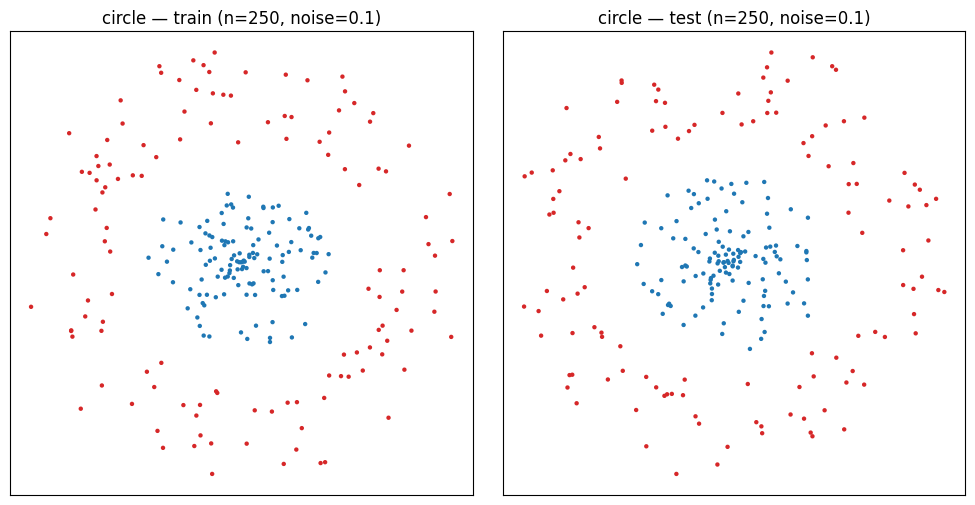

[circle]  gen |    fit max    mean |  acc best tr/te | mean te | species (new/ext,max) | best h/c/d | pop h/c | stag |  time
         0 |   -0.710  -0.723 |      0.52/0.59 |   0.54 |     1 (+1 -0, 120) |   0/  3/ 1 |  0.0/  3.0 |    0 |   7.9s
           sp   0: fit   -0.710 size 120 | h  0 c   3 d  1 | -
         1 |   -0.392  -0.694 |      0.82/0.82 |   0.60 |     1 (+0 -0, 120) |   1/  4/ 2 |  0.2/  3.2 |    0 |   7.9s
           sp   0: fit   -0.392 size 120 | h  1 c   4 d  2 | square:1
         2 |   -0.219  -0.598 |      0.93/0.92 |   0.68 |     7 (+6 -0, 53) |   2/  5/ 2 |  0.7/  3.8 |    0 |   8.2s
           sp   2: fit   -0.219 size  26 | h  2 c   5 d  2 | gauss:1 square:1
           sp   3: fit   -0.329 size   5 | h  1 c   5 d  2 | square:1
           sp   1: fit   -0.341 size  24 | h  1 c   6 d  2 | square:1
         3 |   -0.111  -0.451 |      0.99/1.00 |   0.75 |     8 (+1 -0, 45) |   3/  7/ 3 |  1.2/  5.0 |    0 |   8.2s
           sp   2: fit   -0.111 size  45 | h  3 c 

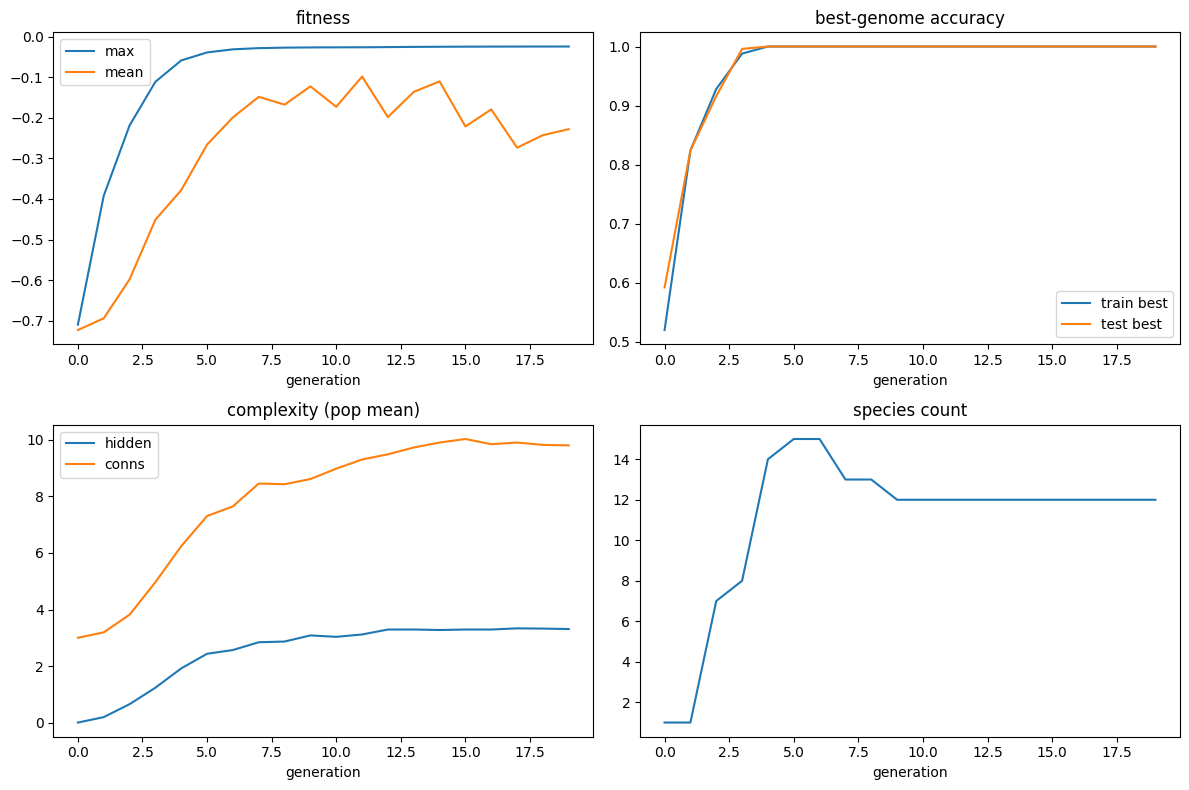

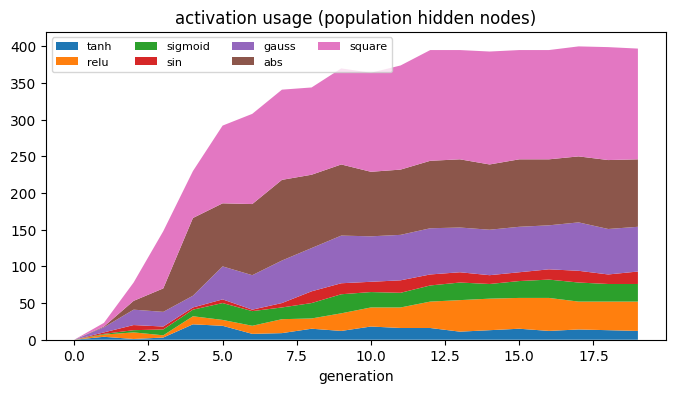

In [2]:
# %% [markdown]
# Backprop NEAT on 2D classification (circle / XOR / spiral) — Colab runner.
# NEAT evolves topology; backprop (Adam) fits the weights of each network.
# Runtime > Change runtime type > GPU is optional (small problems run on CPU too).

# %% Confirm JAX sees a device.
# Colab ships JAX preinstalled and version-matched on a FRESH runtime — do not
# reinstall/upgrade jax (that causes the PJRT "expected 48, got 40" mismatch).
# If you ever hit that error, just Runtime > Disconnect and delete runtime, then
# run from the top.
import jax
print("devices:", jax.devices())   # CudaDevice on GPU runtime, else CPU

# %% Clone the library (BackpropNEAT branch) and make it importable
!rm -rf Neuroevolution
!git clone -b BackpropNEAT https://github.com/yugoguy/Neuroevolution.git
import sys
sys.path.append("/content/Neuroevolution")

# %% Hyperparameters
#@markdown ### Task
dataset = "circle"        #@param ["circle", "xor", "spiral"]
n_train = 250             #@param {type:"integer"}
n_test = 250              #@param {type:"integer"}
noise = 0.1               #@param {type:"number"}

#@markdown ### Run
pop_size = 120            #@param {type:"integer"}
num_generations = 20      #@param {type:"integer"}
n_max = 32                #@param {type:"integer"}
seed = 0                  #@param {type:"integer"}

#@markdown ### Backprop inner loop
backprop_steps = 100      #@param {type:"integer"}
learning_rate = 0.01      #@param {type:"number"}
num_passes = 32           #@param {type:"integer"}

#@markdown ### Complexity penalty
penalty_conn = 0.01       #@param {type:"number"}
penalty_node = 0.0        #@param {type:"number"}

#@markdown ### Initialization
weight_init_std = 0.5     #@param {type:"number"}

#@markdown ### Mutation (structural ops are NEAT's; weight mutation only jitters the backprop warm-start)
p_weight = 0.2            #@param {type:"number"}
perturb_std = 0.1         #@param {type:"number"}
replace_prob = 0.05       #@param {type:"number"}
p_add_connection = 0.3    #@param {type:"number"}
p_add_node = 0.15         #@param {type:"number"}
p_activation = 0.1        #@param {type:"number"}
add_conn_max_tries = 20   #@param {type:"integer"}
new_node_activation = "random"  #@param ["random", "tanh", "relu", "sigmoid", "sin", "gauss", "abs", "square"]

#@markdown ### Crossover
reenable_prob = 0.25             #@param {type:"number"}
inherit_from_fitter_prob = 0.5   #@param {type:"number"}
interspecies_mating_prob = 0.001 #@param {type:"number"}

#@markdown ### Speciation
compat_threshold = 0.75    #@param {type:"number"}
c_unmatched = 1.0         #@param {type:"number"}
c_weight = 0.4            #@param {type:"number"}
normalize_threshold = 0  #@param {type:"integer"}
rep_selection = "random"  #@param ["random", "first"]

#@markdown ### Reproduction
survival_threshold = 0.3        #@param {type:"number"}
elitism_min_species_size = 5    #@param {type:"integer"}
mutate_only_prob = 0.25         #@param {type:"number"}
parent_selection = "uniform"    #@param ["uniform", "fitness_weighted"]
max_stagnation = 15             #@param {type:"integer"}
population_stall = 20           #@param {type:"integer"}

from config import Config
cfg = Config(
    dataset=dataset, n_train=n_train, n_test=n_test, noise=noise,
    pop_size=pop_size, num_generations=num_generations, n_max=n_max, seed=seed,
    backprop_steps=backprop_steps, learning_rate=learning_rate, num_passes=num_passes,
    penalty_conn=penalty_conn, penalty_node=penalty_node,
    weight_init_std=weight_init_std,
    p_weight=p_weight, perturb_std=perturb_std, replace_prob=replace_prob,
    p_add_connection=p_add_connection, p_add_node=p_add_node, p_activation=p_activation,
    add_conn_max_tries=add_conn_max_tries, new_node_activation=new_node_activation,
    reenable_prob=reenable_prob, inherit_from_fitter_prob=inherit_from_fitter_prob,
    interspecies_mating_prob=interspecies_mating_prob,
    compat_threshold=compat_threshold, c_unmatched=c_unmatched, c_weight=c_weight,
    normalize_threshold=normalize_threshold, rep_selection=rep_selection,
    survival_threshold=survival_threshold, elitism_min_species_size=elitism_min_species_size,
    mutate_only_prob=mutate_only_prob, parent_selection=parent_selection,
    max_stagnation=max_stagnation, population_stall=population_stall,
)

# %% Visualize the dataset first (same RNG sequence evolve uses, so this is the
# actual train/test split the networks are scored on)
import numpy as np
import matplotlib.pyplot as plt
from dataset import make_dataset
_drng = np.random.default_rng(cfg.seed + 1)
Xtr, ytr = make_dataset(cfg.dataset, cfg.n_train, _drng, cfg.noise)
Xte, yte = make_dataset(cfg.dataset, cfg.n_test, _drng, cfg.noise)
fig, axd = plt.subplots(1, 2, figsize=(10, 5))
for a, (X, y, name) in zip(axd, [(Xtr, ytr, "train"), (Xte, yte, "test")]):
    a.scatter(X[y == 0, 0], X[y == 0, 1], s=10, c="tab:red", edgecolors="none")
    a.scatter(X[y == 1, 0], X[y == 1, 1], s=10, c="tab:blue", edgecolors="none")
    a.set_title(f"{cfg.dataset} — {name} (n={len(y)}, noise={cfg.noise})")
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# %% Run evolution (first generation is slow due to JIT compilation)
from orchestrator import evolve
best, rec = evolve(cfg)
rec.dump_json("history.json")
print("best fitness:", rec.records[-1]["best"]["fitness"])
print("best test acc:", rec.records[-1].get("accuracy", {}).get("test_best"))

# %% Top-species report (reconstructed from the recorder, so it always prints
# regardless of what orchestrator version produced the run). For the requested
# generations it lists, per top species, the BEST genome's fitness, size,
# structure (hidden / connections / depth) and which activations it uses.
from collections import Counter
from recorder import load_genome
from graph_utils import max_depth

def species_report(gen, top_k=6):
    r = rec.records[gen]
    sfit = {int(s): v for s, v in r["species"]["fitness"].items()}     # {sid:{size,mean,max}}
    snaps = {int(s): g for s, g in rec.species_best_snapshots.get(gen, {}).items()}
    order = sorted(sfit, key=lambda s: sfit[s]["max"], reverse=True)[:top_k]
    acc = r.get("accuracy", {})
    print(f"\n=== gen {gen:>3} | {r['species']['count']} species "
          f"| pop best fit {r['fitness']['max']:.3f} "
          f"(train {acc.get('train_best', 0):.3f} / test {acc.get('test_best', 0):.3f}) ===")
    print(f"{'rank':>4}  {'sp':>4}  {'best fit':>9}  {'size':>4}  "
          f"{'hid':>3}  {'conn':>4}  {'dep':>3}  activations")
    for rank, sid in enumerate(order, 1):
        st = sfit[sid]
        g = load_genome(snaps[sid])
        hid = [n for n in g.node_genes.values() if n.type == "hidden"]
        conns = sum(c.enabled for c in g.conn_genes.values())
        acts = Counter(n.activation for n in hid)
        acts_str = ", ".join(f"{a}x{k}" for a, k in acts.most_common()) or "(none)"
        print(f"{rank:>4}  {sid:>4}  {st['max']:>9.3f}  {st['size']:>4}  "
              f"{len(hid):>3}  {conns:>4}  {max_depth(g):>3}  {acts_str}")

last = len(rec.records) - 1
for gi in sorted({0, last // 2, last}):
    species_report(gi)

# %% Fitness / accuracy / complexity / species over generations
import matplotlib.pyplot as plt
g = [r["gen"] for r in rec.records]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].plot(g, [r["fitness"]["max"] for r in rec.records], label="max")
ax[0, 0].plot(g, [r["fitness"]["mean"] for r in rec.records], label="mean")
ax[0, 0].set_title("fitness"); ax[0, 0].legend()
ax[0, 1].plot(g, [r.get("accuracy", {}).get("train_best", 0) for r in rec.records], label="train best")
ax[0, 1].plot(g, [r.get("accuracy", {}).get("test_best", 0) for r in rec.records], label="test best")
ax[0, 1].set_title("best-genome accuracy"); ax[0, 1].legend()
ax[1, 0].plot(g, [r["complexity"]["hidden"]["mean"] for r in rec.records], label="hidden")
ax[1, 0].plot(g, [r["complexity"]["enabled_conns"]["mean"] for r in rec.records], label="conns")
ax[1, 0].set_title("complexity (pop mean)"); ax[1, 0].legend()
ax[1, 1].plot(g, [r["species"]["count"] for r in rec.records])
ax[1, 1].set_title("species count")
for a in ax.ravel():
    a.set_xlabel("generation")
plt.tight_layout(); plt.show()

# %% Activation usage across the population over time
import numpy as np
names = list(cfg.activation_names)
usage = np.array([[r["activations_population"].get(n, 0) for n in names] for r in rec.records])
plt.figure(figsize=(8, 4))
plt.stackplot(g, usage.T, labels=names)
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.title("activation usage (population hidden nodes)"); plt.xlabel("generation"); plt.show()

# %% Best network topology
from viz import draw_network
from IPython.display import Image
draw_network(best, cfg.num_inputs, cfg.num_outputs, "best_topology.png")
Image("best_topology.png")

# %% Decision boundary of the best network (re-generate the same test set to overlay)
from dataset import make_dataset
from converter import activation_ids
from viz import decision_boundary
data_rng = np.random.default_rng(cfg.seed + 1)
_ = make_dataset(cfg.dataset, cfg.n_train, data_rng, cfg.noise)   # advance rng to match training
Xte, yte = make_dataset(cfg.dataset, cfg.n_test, data_rng, cfg.noise)
decision_boundary(best, cfg.num_inputs, cfg.num_outputs, cfg.n_max,
                  activation_ids(names), names, cfg.num_passes,
                  Xte, yte, "best_boundary.png")
Image("best_boundary.png")

# %% Topology at several generations (complexification story)
from recorder import load_genome
for gi in [0, cfg.num_generations // 2, cfg.num_generations - 1]:
    if gi in rec.best_snapshots:
        draw_network(load_genome(rec.best_snapshots[gi]),
                     cfg.num_inputs, cfg.num_outputs, f"topo_gen{gi}.png")

# SPIRAL

devices: [CudaDevice(id=0)]
Cloning into 'Neuroevolution'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 133 (delta 68), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 76.94 KiB | 4.53 MiB/s, done.
Resolving deltas: 100% (68/68), done.


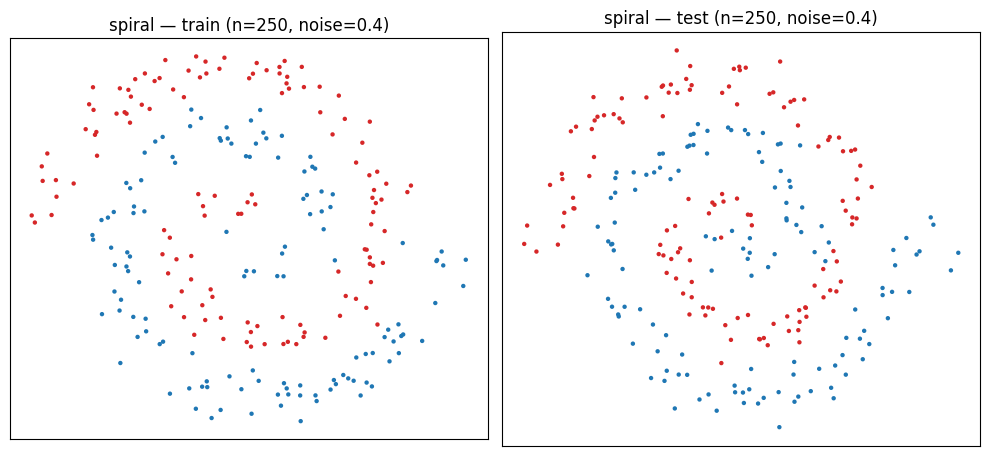

[spiral]  gen |    fit max    mean |  acc best tr/te | mean te | species (new/ext,max) | best h/c/d | pop h/c | stag |  time
         0 |   -0.621  -0.645 |      0.65/0.62 |   0.61 |     1 (+1 -0, 120) |   0/  3/ 1 |  0.0/  3.0 |    0 |   7.9s
           sp   0: fit   -0.621 size 120 | h  0 c   3 d  1 | -
         1 |   -0.621  -0.624 |      0.65/0.62 |   0.62 |     1 (+0 -0, 120) |   0/  3/ 1 |  0.2/  3.2 |    0 |   8.2s
           sp   0: fit   -0.621 size 120 | h  0 c   3 d  1 | -
         2 |   -0.572  -0.623 |      0.77/0.75 |   0.62 |     4 (+3 -0, 98) |   1/  4/ 2 |  0.2/  3.2 |    0 |   8.3s
           sp   3: fit   -0.572 size   8 | h  1 c   4 d  2 | sin:1
           sp   0: fit   -0.621 size  98 | h  0 c   3 d  1 | -
           sp   1: fit   -0.624 size   6 | h  1 c   4 d  2 | sin:1
         3 |   -0.511  -0.606 |      0.79/0.79 |   0.66 |     1 (+0 -3, 120) |   1/  5/ 2 |  0.9/  4.2 |    0 |   7.9s
           sp   0: fit   -0.511 size 120 | h  1 c   5 d  2 | sin:1
         4

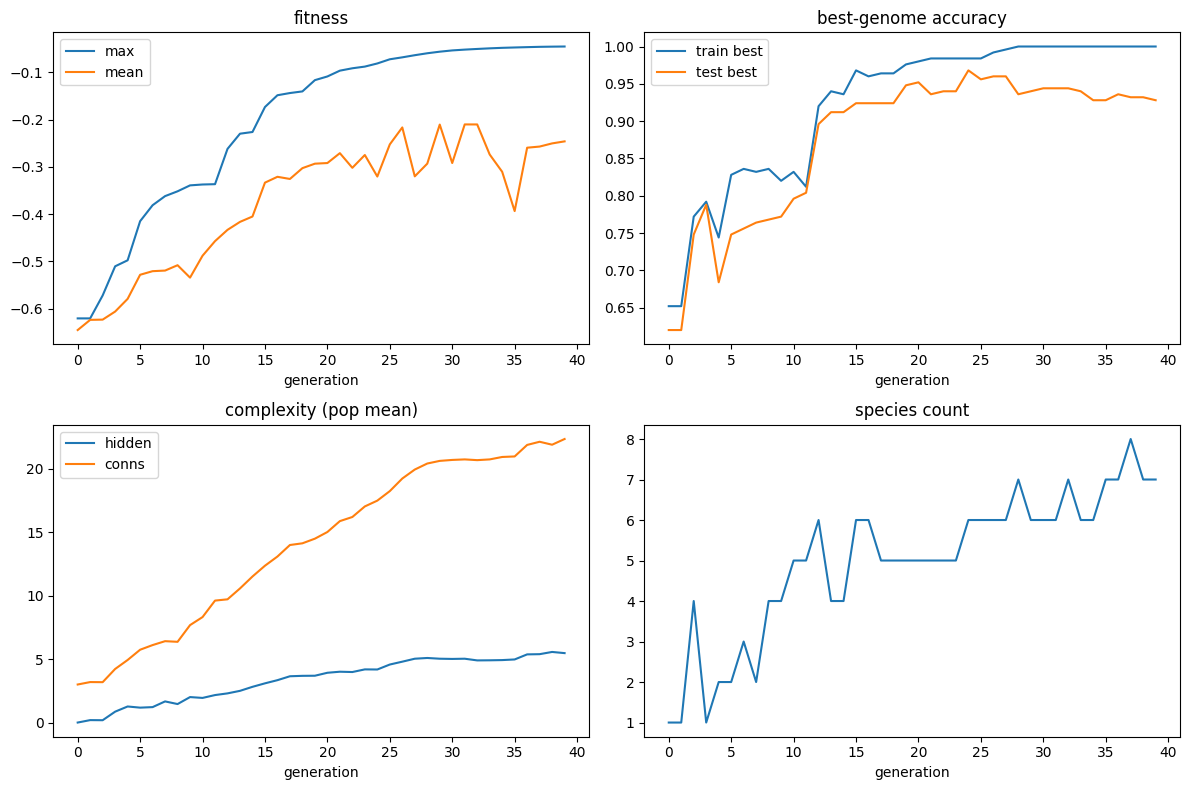

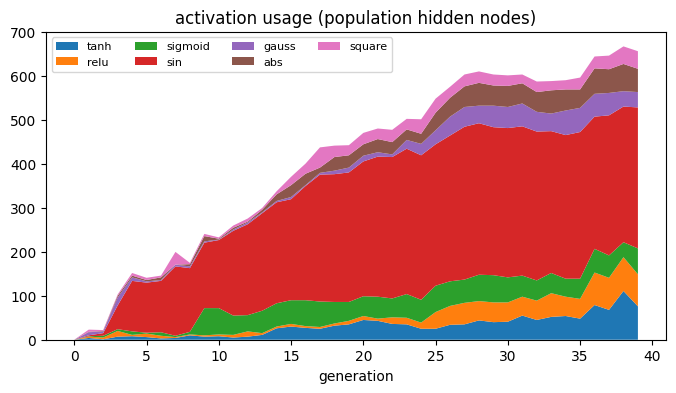

In [5]:
# %% [markdown]
# Backprop NEAT on 2D classification (circle / XOR / spiral) — Colab runner.
# NEAT evolves topology; backprop (Adam) fits the weights of each network.
# Runtime > Change runtime type > GPU is optional (small problems run on CPU too).

# %% Confirm JAX sees a device.
# Colab ships JAX preinstalled and version-matched on a FRESH runtime — do not
# reinstall/upgrade jax (that causes the PJRT "expected 48, got 40" mismatch).
# If you ever hit that error, just Runtime > Disconnect and delete runtime, then
# run from the top.
import jax
print("devices:", jax.devices())   # CudaDevice on GPU runtime, else CPU

# %% Clone the library (BackpropNEAT branch) and make it importable
!rm -rf Neuroevolution
!git clone -b BackpropNEAT https://github.com/yugoguy/Neuroevolution.git
import sys
sys.path.append("/content/Neuroevolution")

# %% Hyperparameters
#@markdown ### Task
dataset = "spiral"        #@param ["circle", "xor", "spiral"]
n_train = 250             #@param {type:"integer"}
n_test = 250              #@param {type:"integer"}
noise = 0.4               #@param {type:"number"}

#@markdown ### Run
pop_size = 120            #@param {type:"integer"}
num_generations = 40      #@param {type:"integer"}
n_max = 32                #@param {type:"integer"}
seed = 0                  #@param {type:"integer"}

#@markdown ### Backprop inner loop
backprop_steps = 100      #@param {type:"integer"}
learning_rate = 0.01      #@param {type:"number"}
num_passes = 32           #@param {type:"integer"}

#@markdown ### Complexity penalty
penalty_conn = 0.01       #@param {type:"number"}
penalty_node = 0.0        #@param {type:"number"}

#@markdown ### Initialization
weight_init_std = 0.5     #@param {type:"number"}

#@markdown ### Mutation (structural ops are NEAT's; weight mutation only jitters the backprop warm-start)
p_weight = 0.2            #@param {type:"number"}
perturb_std = 0.1         #@param {type:"number"}
replace_prob = 0.05       #@param {type:"number"}
p_add_connection = 0.3    #@param {type:"number"}
p_add_node = 0.15         #@param {type:"number"}
p_activation = 0.1        #@param {type:"number"}
add_conn_max_tries = 20   #@param {type:"integer"}
new_node_activation = "random"  #@param ["random", "tanh", "relu", "sigmoid", "sin", "gauss", "abs", "square"]

#@markdown ### Crossover
reenable_prob = 0.25             #@param {type:"number"}
inherit_from_fitter_prob = 0.5   #@param {type:"number"}
interspecies_mating_prob = 0.001 #@param {type:"number"}

#@markdown ### Speciation
compat_threshold = 0.75    #@param {type:"number"}
c_unmatched = 1.0         #@param {type:"number"}
c_weight = 0.4            #@param {type:"number"}
normalize_threshold = 0  #@param {type:"integer"}
rep_selection = "random"  #@param ["random", "first"]

#@markdown ### Reproduction
survival_threshold = 0.3        #@param {type:"number"}
elitism_min_species_size = 5    #@param {type:"integer"}
mutate_only_prob = 0.25         #@param {type:"number"}
parent_selection = "uniform"    #@param ["uniform", "fitness_weighted"]
max_stagnation = 15             #@param {type:"integer"}
population_stall = 20           #@param {type:"integer"}

from config import Config
cfg = Config(
    dataset=dataset, n_train=n_train, n_test=n_test, noise=noise,
    pop_size=pop_size, num_generations=num_generations, n_max=n_max, seed=seed,
    backprop_steps=backprop_steps, learning_rate=learning_rate, num_passes=num_passes,
    penalty_conn=penalty_conn, penalty_node=penalty_node,
    weight_init_std=weight_init_std,
    p_weight=p_weight, perturb_std=perturb_std, replace_prob=replace_prob,
    p_add_connection=p_add_connection, p_add_node=p_add_node, p_activation=p_activation,
    add_conn_max_tries=add_conn_max_tries, new_node_activation=new_node_activation,
    reenable_prob=reenable_prob, inherit_from_fitter_prob=inherit_from_fitter_prob,
    interspecies_mating_prob=interspecies_mating_prob,
    compat_threshold=compat_threshold, c_unmatched=c_unmatched, c_weight=c_weight,
    normalize_threshold=normalize_threshold, rep_selection=rep_selection,
    survival_threshold=survival_threshold, elitism_min_species_size=elitism_min_species_size,
    mutate_only_prob=mutate_only_prob, parent_selection=parent_selection,
    max_stagnation=max_stagnation, population_stall=population_stall,
)

# %% Visualize the dataset first (same RNG sequence evolve uses, so this is the
# actual train/test split the networks are scored on)
import numpy as np
import matplotlib.pyplot as plt
from dataset import make_dataset
_drng = np.random.default_rng(cfg.seed + 1)
Xtr, ytr = make_dataset(cfg.dataset, cfg.n_train, _drng, cfg.noise)
Xte, yte = make_dataset(cfg.dataset, cfg.n_test, _drng, cfg.noise)
fig, axd = plt.subplots(1, 2, figsize=(10, 5))
for a, (X, y, name) in zip(axd, [(Xtr, ytr, "train"), (Xte, yte, "test")]):
    a.scatter(X[y == 0, 0], X[y == 0, 1], s=10, c="tab:red", edgecolors="none")
    a.scatter(X[y == 1, 0], X[y == 1, 1], s=10, c="tab:blue", edgecolors="none")
    a.set_title(f"{cfg.dataset} — {name} (n={len(y)}, noise={cfg.noise})")
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# %% Run evolution (first generation is slow due to JIT compilation)
from orchestrator import evolve
best, rec = evolve(cfg)
rec.dump_json("history.json")
print("best fitness:", rec.records[-1]["best"]["fitness"])
print("best test acc:", rec.records[-1].get("accuracy", {}).get("test_best"))

# %% Top-species report (reconstructed from the recorder, so it always prints
# regardless of what orchestrator version produced the run). For the requested
# generations it lists, per top species, the BEST genome's fitness, size,
# structure (hidden / connections / depth) and which activations it uses.
from collections import Counter
from recorder import load_genome
from graph_utils import max_depth

def species_report(gen, top_k=6):
    r = rec.records[gen]
    sfit = {int(s): v for s, v in r["species"]["fitness"].items()}     # {sid:{size,mean,max}}
    snaps = {int(s): g for s, g in rec.species_best_snapshots.get(gen, {}).items()}
    order = sorted(sfit, key=lambda s: sfit[s]["max"], reverse=True)[:top_k]
    acc = r.get("accuracy", {})
    print(f"\n=== gen {gen:>3} | {r['species']['count']} species "
          f"| pop best fit {r['fitness']['max']:.3f} "
          f"(train {acc.get('train_best', 0):.3f} / test {acc.get('test_best', 0):.3f}) ===")
    print(f"{'rank':>4}  {'sp':>4}  {'best fit':>9}  {'size':>4}  "
          f"{'hid':>3}  {'conn':>4}  {'dep':>3}  activations")
    for rank, sid in enumerate(order, 1):
        st = sfit[sid]
        g = load_genome(snaps[sid])
        hid = [n for n in g.node_genes.values() if n.type == "hidden"]
        conns = sum(c.enabled for c in g.conn_genes.values())
        acts = Counter(n.activation for n in hid)
        acts_str = ", ".join(f"{a}x{k}" for a, k in acts.most_common()) or "(none)"
        print(f"{rank:>4}  {sid:>4}  {st['max']:>9.3f}  {st['size']:>4}  "
              f"{len(hid):>3}  {conns:>4}  {max_depth(g):>3}  {acts_str}")

last = len(rec.records) - 1
for gi in sorted({0, last // 2, last}):
    species_report(gi)

# %% Fitness / accuracy / complexity / species over generations
import matplotlib.pyplot as plt
g = [r["gen"] for r in rec.records]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].plot(g, [r["fitness"]["max"] for r in rec.records], label="max")
ax[0, 0].plot(g, [r["fitness"]["mean"] for r in rec.records], label="mean")
ax[0, 0].set_title("fitness"); ax[0, 0].legend()
ax[0, 1].plot(g, [r.get("accuracy", {}).get("train_best", 0) for r in rec.records], label="train best")
ax[0, 1].plot(g, [r.get("accuracy", {}).get("test_best", 0) for r in rec.records], label="test best")
ax[0, 1].set_title("best-genome accuracy"); ax[0, 1].legend()
ax[1, 0].plot(g, [r["complexity"]["hidden"]["mean"] for r in rec.records], label="hidden")
ax[1, 0].plot(g, [r["complexity"]["enabled_conns"]["mean"] for r in rec.records], label="conns")
ax[1, 0].set_title("complexity (pop mean)"); ax[1, 0].legend()
ax[1, 1].plot(g, [r["species"]["count"] for r in rec.records])
ax[1, 1].set_title("species count")
for a in ax.ravel():
    a.set_xlabel("generation")
plt.tight_layout(); plt.show()

# %% Activation usage across the population over time
import numpy as np
names = list(cfg.activation_names)
usage = np.array([[r["activations_population"].get(n, 0) for n in names] for r in rec.records])
plt.figure(figsize=(8, 4))
plt.stackplot(g, usage.T, labels=names)
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.title("activation usage (population hidden nodes)"); plt.xlabel("generation"); plt.show()

# %% Best network topology
from viz import draw_network
from IPython.display import Image
draw_network(best, cfg.num_inputs, cfg.num_outputs, "best_topology.png")
Image("best_topology.png")

# %% Decision boundary of the best network (re-generate the same test set to overlay)
from dataset import make_dataset
from converter import activation_ids
from viz import decision_boundary
data_rng = np.random.default_rng(cfg.seed + 1)
_ = make_dataset(cfg.dataset, cfg.n_train, data_rng, cfg.noise)   # advance rng to match training
Xte, yte = make_dataset(cfg.dataset, cfg.n_test, data_rng, cfg.noise)
decision_boundary(best, cfg.num_inputs, cfg.num_outputs, cfg.n_max,
                  activation_ids(names), names, cfg.num_passes,
                  Xte, yte, "best_boundary.png")
Image("best_boundary.png")

# %% Topology at several generations (complexification story)
from recorder import load_genome
for gi in [0, cfg.num_generations // 2, cfg.num_generations - 1]:
    if gi in rec.best_snapshots:
        draw_network(load_genome(rec.best_snapshots[gi]),
                     cfg.num_inputs, cfg.num_outputs, f"topo_gen{gi}.png")